In [3]:
!pip install scikit-learn matplotlib imblearn

  Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 56.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 29.5 MB/s eta 0:00:00
Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.7 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 21.4 MB/s eta 0:00:00


In [4]:
import numpy as np
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from imblearn.metrics import sensitivity_score
from imblearn.metrics import specificity_score
from sklearn.metrics import roc_curve, roc_auc_score, auc, precision_recall_curve
from sklearn.metrics import accuracy_score as acc
from sklearn.metrics import f1_score as f1
from sklearn.metrics import classification_report
import math

### EATD - 일반

In [53]:
_tn, _fp, _fn, _tp = 40, 28, 5, 6

yk = np.array([[_tp, _fn], [_fp, _tn]])
tk = np.array([[11, 0], [0, 68]])

print(yk)
print(tk)

tp = [1 for i in range(_tp)]
tn = [0 for i in range(_tn)]
fp = [1 for i in range(_fp)]
fn = [0 for i in range(_fn)]
fyk = tp+fn+fp+tn

dep = [1 for i in range(11)]
normal = [0 for i in range(68)]
ftk = dep+normal

fyk, ftk = np.array(fyk), np.array(ftk)
# print(fyk)
# print(ftk)

target_name = ['Normal', "Depression"]
print(classification_report(ftk, fyk, target_names=target_name))

p, r, _ = precision_recall_curve(ftk, fyk)

print(f"sklenrn accuracy : {round(acc(ftk, fyk),4)}")
print(f"f1 : {round(2/((1/precision_score(ftk, fyk))+(1/recall_score(ftk, fyk))), 4)}")
print(f"sklearn f1-macro : {round(f1(ftk, fyk, average = 'macro'),4)}")
print(f"sklearn ROC AUC : {round(roc_auc_score(ftk, fyk),4)}")
print(f"sklearn PR AUC : {round(auc(r, p),4)}")
print(f"sklearn specificity : {round(specificity_score(ftk, fyk),4)}")
print(f"sklearn sensitivity : {round(sensitivity_score(ftk, fyk),4)}")
print(f"sklearn precision : {round(precision_score(ftk, fyk),4)}")
print(f"sklearn recall : {round(recall_score(ftk, fyk),4)}")
# print(f"f1 : {round(2/((1/precision_score(ftk, fyk))+(1/recall_score(ftk, fyk))), 4)}")
#print(f"sklearn f1-weighted : {round(f1(ftk, fyk, average = 'weighted')*100,2)}")
#print(f"sklearn MAE : {round(mae(tk, yk),2)}")
#print(f"sklearn RMSE : {round((mse(tk, yk))**0.5, 2)}")

[[ 6  5]
 [28 40]]
[[11  0]
 [ 0 68]]
              precision    recall  f1-score   support

      Normal       0.89      0.59      0.71        68
  Depression       0.18      0.55      0.27        11

    accuracy                           0.58        79
   macro avg       0.53      0.57      0.49        79
weighted avg       0.79      0.58      0.65        79

sklenrn accuracy : 0.5823
f1 : 0.2667
sklearn f1-macro : 0.4873
sklearn ROC AUC : 0.5668
sklearn PR AUC : 0.3926
sklearn specificity : 0.5882
sklearn sensitivity : 0.5455
sklearn precision : 0.1765
sklearn recall : 0.5455


### EATD - balance

In [58]:
_tn, _fp, _fn, _tp = 34, 34, 11, 55

yk = np.array([[_tp, _fn], [_fp, _tn]])
tk = np.array([[66, 0], [0, 68]])

print(yk)
print(tk)

tp = [1 for i in range(_tp)]
tn = [0 for i in range(_tn)]
fp = [1 for i in range(_fp)]
fn = [0 for i in range(_fn)]
fyk = tp+fn+fp+tn

dep = [1 for i in range(66)]
normal = [0 for i in range(68)]
ftk = dep+normal
fyk, ftk = np.array(fyk), np.array(ftk)
# print(fyk)
# print(ftk)

target_name = ['Normal', "Depression"]
print(classification_report(ftk, fyk, target_names=target_name))

p, r, _ = precision_recall_curve(ftk, fyk)

print(f"sklenrn accuracy : {round(acc(ftk, fyk),4)}")
print(f"f1 : {round(2/((1/precision_score(ftk, fyk))+(1/recall_score(ftk, fyk))), 4)}")
print(f"sklearn f1-macro : {round(f1(ftk, fyk, average = 'macro'),4)}")
print(f"sklearn ROC AUC : {round(roc_auc_score(ftk, fyk),4)}")
print(f"sklearn PR AUC : {round(auc(r, p),4)}")
print(f"sklearn specificity : {round(specificity_score(ftk, fyk),4)}")
print(f"sklearn sensitivity : {round(sensitivity_score(ftk, fyk),4)}")
print(f"sklearn precision : {round(precision_score(ftk, fyk),4)}")
print(f"sklearn recall : {round(recall_score(ftk, fyk),4)}")
# print(f"f1 : {round(2/((1/precision_score(ftk, fyk))+(1/recall_score(ftk, fyk))), 4)}")
#print(f"sklearn f1-weighted : {round(f1(ftk, fyk, average = 'weighted')*100,2)}")
#print(f"sklearn MAE : {round(mae(tk, yk),2)}")
#print(f"sklearn RMSE : {round((mse(tk, yk))**0.5, 2)}")

[[55 11]
 [34 34]]
[[66  0]
 [ 0 68]]
              precision    recall  f1-score   support

      Normal       0.76      0.50      0.60        68
  Depression       0.62      0.83      0.71        66

    accuracy                           0.66       134
   macro avg       0.69      0.67      0.66       134
weighted avg       0.69      0.66      0.65       134

sklenrn accuracy : 0.6642
f1 : 0.7097
sklearn f1-macro : 0.6557
sklearn ROC AUC : 0.6667
sklearn PR AUC : 0.7667
sklearn specificity : 0.5
sklearn sensitivity : 0.8333
sklearn precision : 0.618
sklearn recall : 0.8333


### DAICWOZ

In [60]:
_tn, _fp, _fn, _tp = 19, 4, 4, 8

yk = np.array([[_tp, _fn], [_fp, _tn]])
tk = np.array([[12, 0], [0, 23]])

print(yk)
print(tk)

tp = [1 for i in range(_tp)]
tn = [0 for i in range(_tn)]
fp = [1 for i in range(_fp)]
fn = [0 for i in range(_fn)]
fyk = tp+fn+fp+tn

dep = [1 for i in range(12)]
normal = [0 for i in range(23)]
ftk = dep+normal
fyk, ftk = np.array(fyk), np.array(ftk)

target_name = ['Normal', "Depression"]
print(classification_report(ftk, fyk, target_names=target_name, digits=4))

p, r, _ = precision_recall_curve(ftk, fyk)

# print(f"f1_MDD : {round(2/((1/precision_score(ftk, fyk))+(1/recall_score(ftk, fyk))), 4)}")
print(f"sklearn precision : {round(precision_score(ftk, fyk),4)}")
print(f"sklearn recall : {round(recall_score(ftk, fyk),4)}")
print(f"sklearn sensitivity : {round(sensitivity_score(ftk, fyk),4)}")
print(f"sklearn specificity : {round(specificity_score(ftk, fyk),4)}")
print(f"sklearn f1-macro : {round(f1(ftk, fyk, average = 'macro'),4)}")
print(f"sklenrn accuracy : {round(acc(ftk, fyk),4)}")
print(f"sklearn ROC AUC : {round(roc_auc_score(ftk, fyk),4)}")
print(f"sklearn PR AUC : {round(auc(r, p),4)}")

[[ 8  4]
 [ 4 19]]
[[12  0]
 [ 0 23]]
              precision    recall  f1-score   support

      Normal     0.8261    0.8261    0.8261        23
  Depression     0.6667    0.6667    0.6667        12

    accuracy                         0.7714        35
   macro avg     0.7464    0.7464    0.7464        35
weighted avg     0.7714    0.7714    0.7714        35

sklearn precision : 0.6667
sklearn recall : 0.6667
sklearn sensitivity : 0.6667
sklearn specificity : 0.8261
sklearn f1-macro : 0.7464
sklenrn accuracy : 0.7714
sklearn ROC AUC : 0.7464
sklearn PR AUC : 0.7238


In [30]:
_tn, _fp, _fn, _tp = 14, 9, 6, 6

yk = np.array([[_tp, _fn], [_fp, _tn]])
tk = np.array([[7, 0], [0, 28]])

print(yk)
print(tk)

tp = [1 for i in range(_tp)]
tn = [0 for i in range(_tn)]
fp = [1 for i in range(_fp)]
fn = [0 for i in range(_fn)]
fyk = tp+fn+fp+tn

dep = [1 for i in range(7)]
normal = [0 for i in range(28)]
ftk = dep+normal
fyk, ftk = np.array(fyk), np.array(ftk)

target_name = ['Normal', "Depression"]
print(classification_report(ftk, fyk, target_names=target_name, digits=4))

p, r, _ = precision_recall_curve(ftk, fyk)

# print(f"f1_MDD : {round(2/((1/precision_score(ftk, fyk))+(1/recall_score(ftk, fyk))), 4)}")
print(f"sklearn precision : {round(precision_score(ftk, fyk),4)}")
print(f"sklearn recall : {round(recall_score(ftk, fyk),4)}")
print(f"sklearn sensitivity : {round(sensitivity_score(ftk, fyk),4)}")
print(f"sklearn specificity : {round(specificity_score(ftk, fyk),4)}")
print(f"sklearn f1-macro : {round(f1(ftk, fyk, average = 'macro'),4)}")
print(f"sklenrn accuracy : {round(acc(ftk, fyk),4)}")
print(f"sklearn ROC AUC : {round(roc_auc_score(ftk, fyk),4)}")
print(f"sklearn PR AUC : {round(auc(r, p),4)}")

[[ 6  6]
 [ 9 14]]
[[ 7  0]
 [ 0 28]]
              precision    recall  f1-score   support

      Normal     0.9500    0.6786    0.7917        28
  Depression     0.4000    0.8571    0.5455         7

    accuracy                         0.7143        35
   macro avg     0.6750    0.7679    0.6686        35
weighted avg     0.8400    0.7143    0.7424        35

sklearn precision : 0.4
sklearn recall : 0.8571
sklearn sensitivity : 0.8571
sklearn specificity : 0.6786
sklearn f1-macro : 0.6686
sklenrn accuracy : 0.7143
sklearn ROC AUC : 0.7679
sklearn PR AUC : 0.6429


In [140]:
_tn, _fp, _fn, _tp = 24, 8, 2, 12

yk = np.array([[_tp, _fn], [_fp, _tn]])
tk = np.array([[14, 0], [0, 32]])

print(yk)
print(tk)

tp = [1 for i in range(_tp)]
tn = [0 for i in range(_tn)]
fp = [1 for i in range(_fp)]
fn = [0 for i in range(_fn)]
fyk = tp+fn+fp+tn

dep = [1 for i in range(14)]
normal = [0 for i in range(32)]
ftk = dep+normal
fyk, ftk = np.array(fyk), np.array(ftk)

target_name = ['Normal', "Depression"]
print(classification_report(ftk, fyk, target_names=target_name, digits=4))

p, r, _ = precision_recall_curve(ftk, fyk)

# print(f"f1_MDD : {round(2/((1/precision_score(ftk, fyk))+(1/recall_score(ftk, fyk))), 4)}")
print(f"sklearn precision : {round(precision_score(ftk, fyk),4)}")
print(f"sklearn recall : {round(recall_score(ftk, fyk),4)}")
print(f"sklearn sensitivity : {round(sensitivity_score(ftk, fyk),4)}")
print(f"sklearn specificity : {round(specificity_score(ftk, fyk),4)}")
print(f"sklearn f1-macro : {round(f1(ftk, fyk, average = 'macro'),4)}")
print(f"sklenrn accuracy : {round(acc(ftk, fyk),4)}")
print(f"sklearn ROC AUC : {round(roc_auc_score(ftk, fyk),4)}")
print(f"sklearn PR AUC : {round(auc(r, p),4)}")

[[12  2]
 [ 8 24]]
[[14  0]
 [ 0 32]]
              precision    recall  f1-score   support

      Normal     0.9231    0.7500    0.8276        32
  Depression     0.6000    0.8571    0.7059        14

    accuracy                         0.7826        46
   macro avg     0.7615    0.8036    0.7667        46
weighted avg     0.8247    0.7826    0.7905        46

sklearn precision : 0.6
sklearn recall : 0.8571
sklearn sensitivity : 0.8571
sklearn specificity : 0.75
sklearn f1-macro : 0.7667
sklenrn accuracy : 0.7826
sklearn ROC AUC : 0.8036
sklearn PR AUC : 0.7503


## E-DAIC

In [24]:
_tn, _fp, _fn, _tp = 39, 1, 9, 6

yk = np.array([[_tp, _fn], [_fp, _tn]])
tk = np.array([[15, 0], [0, 40]])

print(yk)
print(tk)

tp = [1 for i in range(_tp)]
tn = [0 for i in range(_tn)]
fp = [1 for i in range(_fp)]
fn = [0 for i in range(_fn)]
fyk = tp+fn+fp+tn

dep = [1 for i in range(15)]
normal = [0 for i in range(40)]
ftk = dep+normal
fyk, ftk = np.array(fyk), np.array(ftk)

target_name = ['Normal', "Depression"]
print(classification_report(ftk, fyk, target_names=target_name))

p, r, _ = precision_recall_curve(ftk, fyk)

# print(f"f1 : {round(2/((1/precision_score(ftk, fyk))+(1/recall_score(ftk, fyk))), 4)}")
# print(f"sklearn precision : {round(precision_score(ftk, fyk),4)}")
# print(f"sklearn recall : {round(recall_score(ftk, fyk),4)}")
# print(f"sklearn sensitivity : {round(sensitivity_score(ftk, fyk),4)}")
# print(f"sklearn specificity : {round(specificity_score(ftk, fyk),4)}")
# print(f"sklearn f1-macro : {round(f1(ftk, fyk, average = 'macro'),4)}")
# print(f"sklenrn accuracy : {round(acc(ftk, fyk),4)}")
# print(f"sklearn ROC AUC : {round(roc_auc_score(ftk, fyk),4)}")
# print(f"sklearn PR AUC : {round(auc(r, p),4)}")


print(f"sklearn ROC AUC : {round(roc_auc_score(ftk, fyk),4)}")
print(f"sklearn PR AUC : {round(auc(r, p),4)}")
print(f"sklenrn accuracy : {round(acc(ftk, fyk),4)}")
print(f"sklearn f1-macro : {round(f1(ftk, fyk, average = 'macro'),4)}")

[[ 6  9]
 [ 1 39]]
[[15  0]
 [ 0 40]]
              precision    recall  f1-score   support

      Normal       0.81      0.97      0.89        40
  Depression       0.86      0.40      0.55        15

    accuracy                           0.82        55
   macro avg       0.83      0.69      0.72        55
weighted avg       0.82      0.82      0.79        55

sklearn ROC AUC : 0.6875
sklearn PR AUC : 0.7104
sklenrn accuracy : 0.8182
sklearn f1-macro : 0.7159


In [106]:
print(f"sklearn precision : {round(precision_score(ftk, fyk),2)}")
print(f"sklearn recall : {round(recall_score(ftk, fyk),2)}")
print(f"f1 : {round(2/((1/precision_score(ftk, fyk))+(1/recall_score(ftk, fyk))), 2)}")
print(f"sklearn f1-macro : {round(f1(ftk, fyk, average = 'macro'),2)}")
#print(f"sklearn f1-weighted : {round(f1(ftk, fyk, average = 'weighted')*100,2)}")
#print(f"sklearn MAE : {round(mae(tk, yk),2)}")
#print(f"sklearn RMSE : {round((mse(tk, yk))**0.5, 2)}")
print(f"sklearn specificity : {round(specificity_score(ftk, fyk),2)}")
print(f"sklearn sensitivity : {round(sensitivity_score(ftk, fyk),2)}")
print(f"sklearn ROC AUC : {roc_auc_score(ftk, fyk)}")

sklearn precision : 0.75
sklearn recall : 0.2
f1 : 0.32
sklearn f1-macro : 0.59
sklearn specificity : 0.98
sklearn sensitivity : 0.2
sklearn ROC AUC : 0.5874999999999999


---

In [731]:
_tn, _fp, _fn, _tp = 11, 12, 6, 22

#yk = np.array([[_tp, _fn], [_fp, _tn]])
#tk = np.array([[42, 0], [0, 13]])
#tk = np.array([[12, 0], [0, 23]])

yk = np.array([[_tp, _fn], [_fp, _tn]])
tk = np.array([[28, 0], [0, 27]])

print(yk)
print(tk)

tp = [1 for i in range(_tp)]
tn = [0 for i in range(_tn)]
fp = [1 for i in range(_fp)]
fn = [0 for i in range(_fn)]
fyk = tp+fn+fp+tn

dep = [1 for i in range(28)]
normal = [0 for i in range(27)]
ftk = dep+normal

#normal = [0 for i in range(27)]
#dep = [1 for i in range(28)]
fyk, ftk = np.array(fyk), np.array(ftk)
print(fyk)
print(ftk)


[[22  6]
 [12 11]]
[[28  0]
 [ 0 27]]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1
 1 1 1 0 0 0 0 0 0 0 0 0 0 0]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [10]:
print(f"sklearn ACC : {round(acc(fyk, ftk)*100, 2)}")
print(f"sklearn f1-weighted : {round(f1(ftk, fyk, average = 'weighted')*100,2)}")
print(f"sklearn MAE : {round(mae(yk, tk),2)}")
print(f"sklearn RMSE : {round((mse(yk, tk))**0.5, 2)}")
print(f"sklearn precision : {round(precision_score(fyk, ftk),2)}")
print(f"sklearn recall : {round(recall_score(fyk, ftk),2)}")
print(f"f1 : {round(2/((1/precision_score(fyk, ftk))+(1/recall_score(fyk, ftk))), 2)}")
print(f"sklearn f1-macro : {round(f1(fyk, ftk, average = 'macro'),2)}")
print(f"sklearn specificity : {round(_tn/(_tn+_fp),2)}")
print(f"sklearn sensitivity : {round(_tp/(_tp+_fn),2)}")

sklearn ACC : 74.29
sklearn f1-weighted : 74.82
sklearn MAE : 4.5
sklearn RMSE : 4.74
sklearn precision : 0.75
sklearn recall : 0.6
f1 : 0.67
sklearn f1-macro : 0.73
sklearn specificity : 0.74
sklearn sensitivity : 0.75


___

In [491]:
print(f"sklearn ACC : {acc(fyk, ftk)}")
print(f"sklearn f1-weighted : {f1(ftk, fyk, average = 'weighted')}")
print(f"sklearn f1-macro : {f1(fyk, ftk, average = 'macro')}")
print(f"sklearn f1-micro : {f1(fyk, ftk, average = 'micro')}")
print(f"sklearn MAE : {mae(yk, tk)}")
print(f"sklearn MSE : {mse(yk, tk)}")
print(f"sklearn RMSE : {(mse(yk, tk))**0.5}")
precision, recall = len(tp)/(len(tp)+len(fp)), len(tp)/(len(tp)+len(fn))
print(f"precision : {precision}")
print(f"recall : {recall}")
print(f"f1 : {round(2/((1/precision)+(1/recall)), 2)}")
print(f"sklearn precision : {precision_score(fyk, ftk)}")
print(f"sklearn recall : {recall_score(fyk, ftk)}")

sklearn ACC : 0.6
sklearn f1-weighted : 0.560233918128655
sklearn f1-macro : 0.557748538011696
sklearn f1-micro : 0.6
sklearn MAE : 11.0
sklearn MSE : 185.0
sklearn RMSE : 13.601470508735444
precision : 0.5681818181818182
recall : 0.8928571428571429
f1 : 0.69
sklearn precision : 0.8928571428571429
sklearn recall : 0.5681818181818182


In [46]:
precision = 0.8
recall = 0.33
print(round(2/((1/precision)+(1/recall)), 2))

0.47


In [314]:
9/12

0.75

In [745]:
file = [f for f in open(f"./data/train_daicwoz_ori_prep_ver4_reverse.txt").readlines()]

In [746]:
for i in range(len(file)):
    print(file[i].replace("\n", ""))
    print(file[i].replace("\n", ""))
    print(file[i].replace("\n", ""))
    print(file[i].replace("\n", ""))
    print(file[i].replace("\n", ""))

../../download_EDAIC/303_P/303_AUDIO.wav
../../download_EDAIC/303_P/303_AUDIO.wav
../../download_EDAIC/303_P/303_AUDIO.wav
../../download_EDAIC/303_P/303_AUDIO.wav
../../download_EDAIC/303_P/303_AUDIO.wav
../../download_EDAIC/304_P/304_AUDIO.wav
../../download_EDAIC/304_P/304_AUDIO.wav
../../download_EDAIC/304_P/304_AUDIO.wav
../../download_EDAIC/304_P/304_AUDIO.wav
../../download_EDAIC/304_P/304_AUDIO.wav
../../download_EDAIC/310_P/310_AUDIO.wav
../../download_EDAIC/310_P/310_AUDIO.wav
../../download_EDAIC/310_P/310_AUDIO.wav
../../download_EDAIC/310_P/310_AUDIO.wav
../../download_EDAIC/310_P/310_AUDIO.wav
../../download_EDAIC/312_P/312_AUDIO.wav
../../download_EDAIC/312_P/312_AUDIO.wav
../../download_EDAIC/312_P/312_AUDIO.wav
../../download_EDAIC/312_P/312_AUDIO.wav
../../download_EDAIC/312_P/312_AUDIO.wav
../../download_EDAIC/315_P/315_AUDIO.wav
../../download_EDAIC/315_P/315_AUDIO.wav
../../download_EDAIC/315_P/315_AUDIO.wav
../../download_EDAIC/315_P/315_AUDIO.wav
../../download_E

### matplot

> 전체 데이터

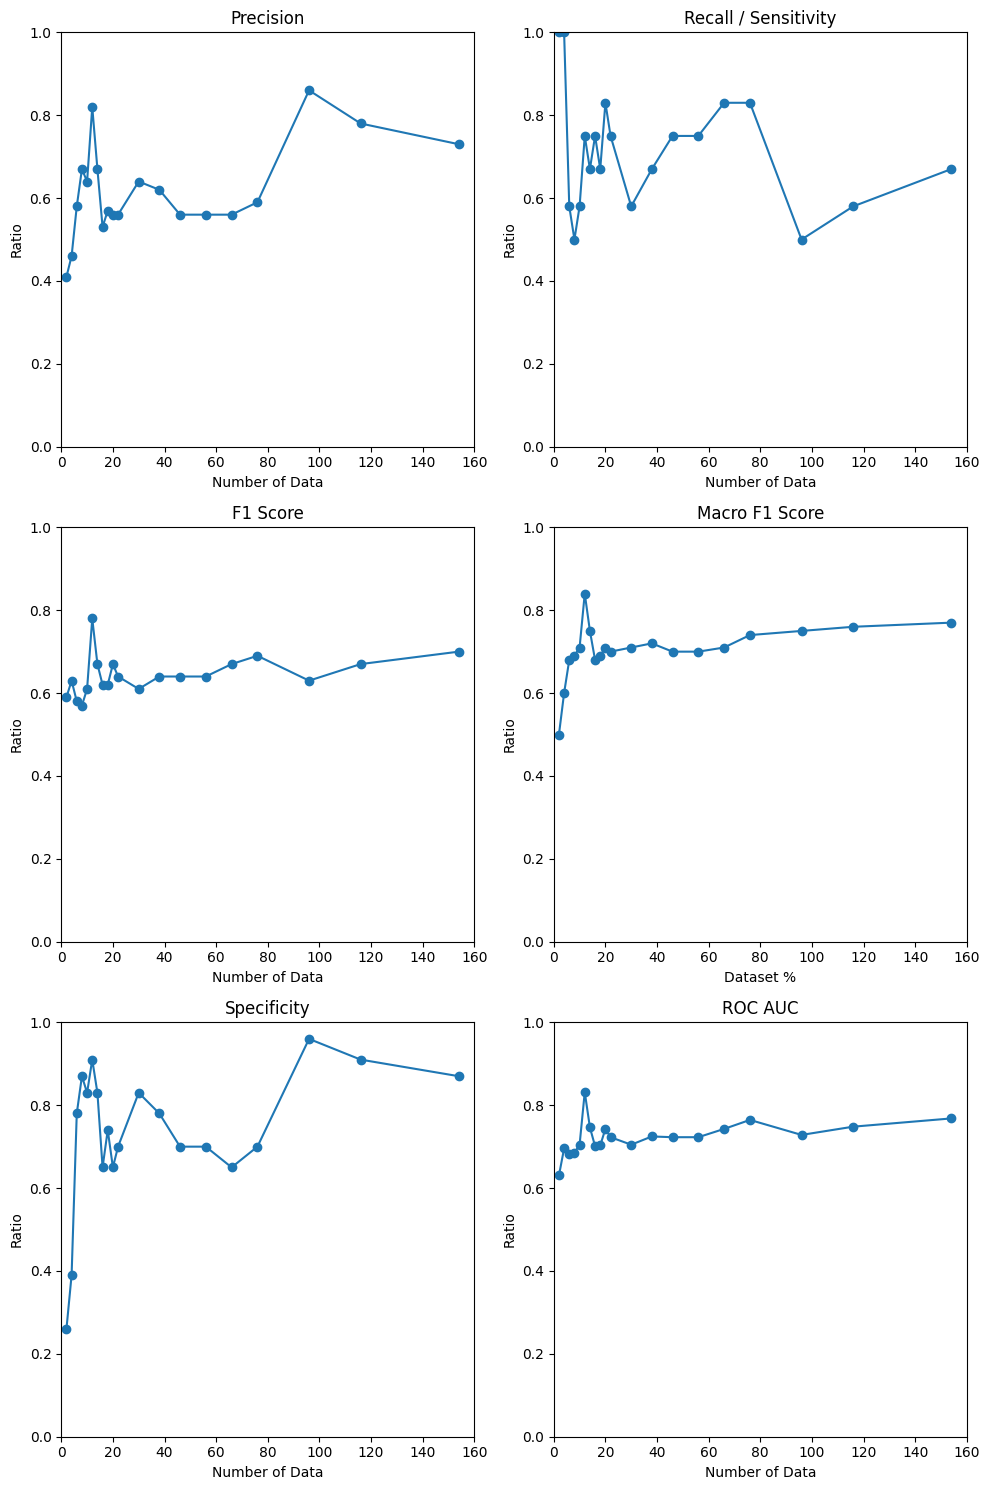

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 준비
X = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 30, 38, 46, 56, 66, 76, 96, 116, 154]
prec = [0.41, 0.46, 0.58, 0.67, 0.64, 0.82, 0.67, 0.53, 0.57, 0.56, 0.56, 0.64, 0.62, 0.56, 0.56, 0.56, 0.59, 0.86, 0.78, 0.73]
rec = [1, 1, 0.58, 0.5, 0.58, 0.75, 0.67, 0.75, 0.67, 0.83, 0.75, 0.58, 0.67, 0.75, 0.75, 0.83, 0.83, 0.5, 0.58, 0.67]
f1 = [0.59, 0.63, 0.58, 0.57, 0.61, 0.78, 0.67, 0.62, 0.62, 0.67, 0.64, 0.61, 0.64, 0.64, 0.64, 0.67, 0.69, 0.63, 0.67, 0.7]
macro_f1 = [0.5, 0.6, 0.68, 0.69, 0.71, 0.84, 0.75, 0.68, 0.69, 0.71, 0.7, 0.71, 0.72, 0.7, 0.7, 0.71, 0.74, 0.75, 0.76, 0.77]
spec = [0.26, 0.39, 0.78, 0.87, 0.83, 0.91, 0.83, 0.65, 0.74, 0.65, 0.7, 0.83, 0.78, 0.7, 0.7, 0.65, 0.7, 0.96, 0.91, 0.87]
sens = [1, 1, 0.58, 0.5, 0.58, 0.75, 0.67, 0.75, 0.67, 0.83, 0.75, 0.58, 0.67, 0.75, 0.75, 0.83, 0.83, 0.5, 0.58, 0.67]
roc_auc = [0.6304, 0.6957, 0.683, 0.6848, 0.7047, 0.8315, 0.7464, 0.7011, 0.7029, 0.7428, 0.7228, 0.7047, 0.7246, 0.7228, 0.7228, 0.7428, 0.7645, 0.7283, 0.7482, 0.7681]

# subplot 설정
fig, axs = plt.subplots(3, 2, figsize=(10, 15))

# 각 subplot에 데이터 그리기
axs[0, 0].plot(X, prec, marker='o', linestyle='-')
axs[0, 0].set_title('Precision')
axs[0, 0].set_xlabel('Number of Data')
axs[0, 0].set_ylabel('Ratio')
axs[0, 0].set_xlim([0, 160])
axs[0, 0].set_ylim([0, 1])

axs[0, 1].plot(X, rec, marker='o', linestyle='-')
axs[0, 1].set_title('Recall / Sensitivity')
axs[0, 1].set_xlabel('Number of Data')
axs[0, 1].set_ylabel('Ratio')
axs[0, 1].set_xlim([0, 160])
axs[0, 1].set_ylim([0, 1])

axs[1, 0].plot(X, f1, marker='o', linestyle='-')
axs[1, 0].set_title('F1 Score')
axs[1, 0].set_xlabel('Number of Data')
axs[1, 0].set_ylabel('Ratio')
axs[1, 0].set_xlim([0, 160])
axs[1, 0].set_ylim([0, 1])

axs[1, 1].plot(X, macro_f1, marker='o', linestyle='-')
axs[1, 1].set_title('Macro F1 Score')
axs[1, 1].set_xlabel('Dataset %')
axs[1, 1].set_ylabel('Ratio')
axs[1, 1].set_xlim([0, 160])
axs[1, 1].set_ylim([0, 1])

axs[2, 0].plot(X, spec, marker='o', linestyle='-')
axs[2, 0].set_title('Specificity')
axs[2, 0].set_xlabel('Number of Data')
axs[2, 0].set_ylabel('Ratio')
axs[2, 0].set_xlim([0, 160])
axs[2, 0].set_ylim([0, 1])

axs[2, 1].plot(X, roc_auc, marker='o', linestyle='-')
axs[2, 1].set_title('ROC AUC')
axs[2, 1].set_xlabel('Number of Data')
axs[2, 1].set_ylabel('Ratio')
axs[2, 1].set_xlim([0, 160])
axs[2, 1].set_ylim([0, 1])

# 레이아웃 조정 및 그래프 표시
plt.tight_layout()
plt.show()


> 데이터를 제한

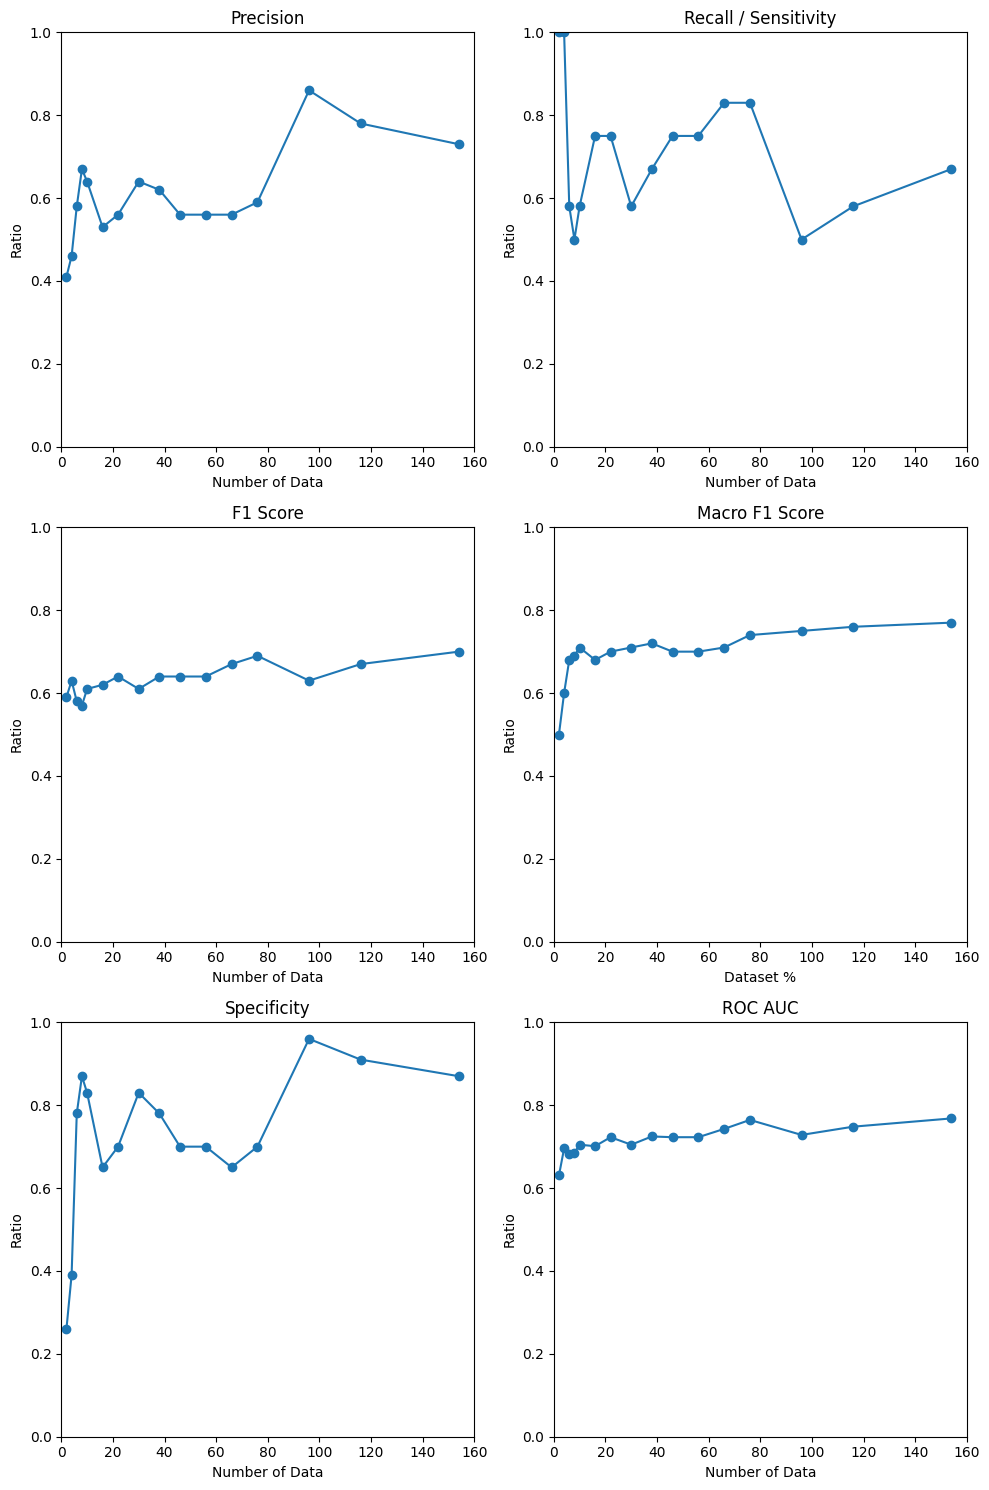

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 준비
X = [2, 4, 6, 8, 10, 16, 22, 30, 38, 46, 56, 66, 76, 96, 116, 154]
prec = [0.41, 0.46, 0.58, 0.67, 0.64, 0.53, 0.56, 0.64, 0.62, 0.56, 0.56, 0.56, 0.59, 0.86, 0.78, 0.73]
rec = [1, 1, 0.58, 0.5, 0.58, 0.75, 0.75, 0.58, 0.67, 0.75, 0.75, 0.83, 0.83, 0.5, 0.58, 0.67]
f1 = [0.59, 0.63, 0.58, 0.57, 0.61, 0.62, 0.64, 0.61, 0.64, 0.64, 0.64, 0.67, 0.69, 0.63, 0.67, 0.7]
macro_f1 = [0.5, 0.6, 0.68, 0.69, 0.71, 0.68, 0.7, 0.71, 0.72, 0.7, 0.7, 0.71, 0.74, 0.75, 0.76, 0.77]
spec = [0.26, 0.39, 0.78, 0.87, 0.83, 0.65, 0.7, 0.83, 0.78, 0.7, 0.7, 0.65, 0.7, 0.96, 0.91, 0.87]
sens = [1, 1, 0.58, 0.5, 0.58, 0.75, 0.75, 0.58, 0.67, 0.75, 0.75, 0.83, 0.83, 0.5, 0.58, 0.67]
roc_auc = [0.6304, 0.6957, 0.683, 0.6848, 0.7047, 0.7011, 0.7228, 0.7047, 0.7246, 0.7228, 0.7228, 0.7428, 0.7645, 0.7283, 0.7482, 0.7681]


# subplot 설정
fig, axs = plt.subplots(3, 2, figsize=(10, 15))

# 각 subplot에 데이터 그리기
axs[0, 0].plot(X, prec, marker='o', linestyle='-')
axs[0, 0].set_title('Precision')
axs[0, 0].set_xlabel('Number of Data')
axs[0, 0].set_ylabel('Ratio')
axs[0, 0].set_xlim([0, 160])
axs[0, 0].set_ylim([0, 1])

axs[0, 1].plot(X, rec, marker='o', linestyle='-')
axs[0, 1].set_title('Recall / Sensitivity')
axs[0, 1].set_xlabel('Number of Data')
axs[0, 1].set_ylabel('Ratio')
axs[0, 1].set_xlim([0, 160])
axs[0, 1].set_ylim([0, 1])

axs[1, 0].plot(X, f1, marker='o', linestyle='-')
axs[1, 0].set_title('F1 Score')
axs[1, 0].set_xlabel('Number of Data')
axs[1, 0].set_ylabel('Ratio')
axs[1, 0].set_xlim([0, 160])
axs[1, 0].set_ylim([0, 1])

axs[1, 1].plot(X, macro_f1, marker='o', linestyle='-')
axs[1, 1].set_title('Macro F1 Score')
axs[1, 1].set_xlabel('Dataset %')
axs[1, 1].set_ylabel('Ratio')
axs[1, 1].set_xlim([0, 160])
axs[1, 1].set_ylim([0, 1])

axs[2, 0].plot(X, spec, marker='o', linestyle='-')
axs[2, 0].set_title('Specificity')
axs[2, 0].set_xlabel('Number of Data')
axs[2, 0].set_ylabel('Ratio')
axs[2, 0].set_xlim([0, 160])
axs[2, 0].set_ylim([0, 1])

axs[2, 1].plot(X, roc_auc, marker='o', linestyle='-')
axs[2, 1].set_title('ROC AUC')
axs[2, 1].set_xlabel('Number of Data')
axs[2, 1].set_ylabel('Ratio')
axs[2, 1].set_xlim([0, 160])
axs[2, 1].set_ylim([0, 1])

# 레이아웃 조정 및 그래프 표시
plt.tight_layout()
plt.show()


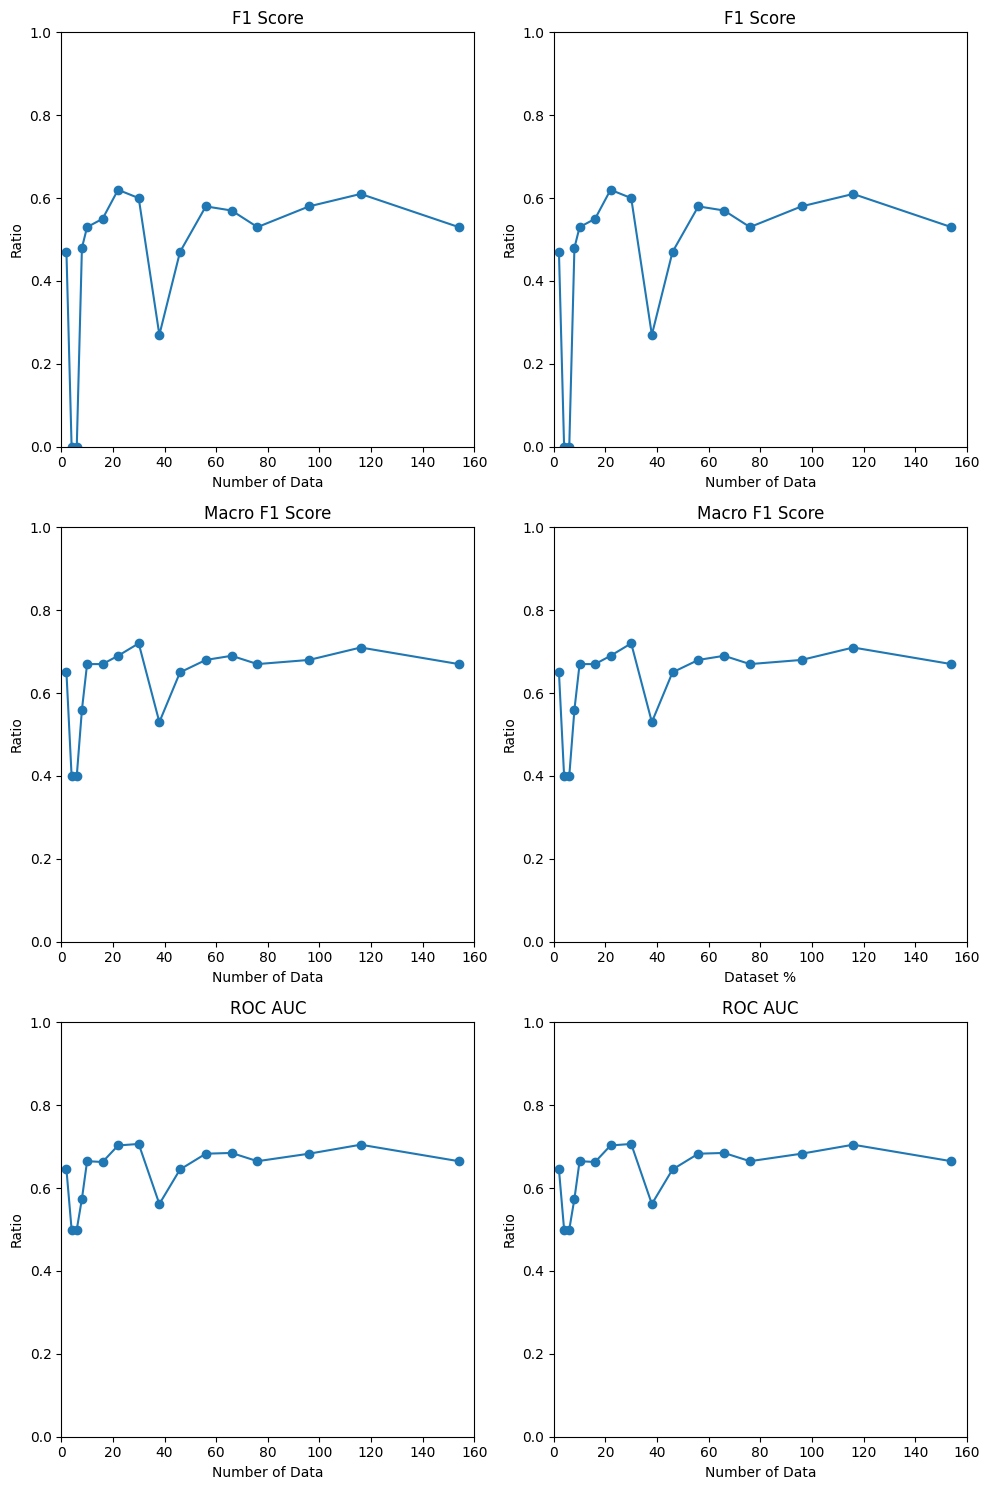

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 준비
X = [2, 4, 6, 8, 10, 16, 22, 30, 38, 46, 56, 66, 76, 96, 116, 154]
prec     = [0.80, 0.00, 0.00, 0.41, 0.71, 0.60, 0.57, 0.75, 0.67, 0.80, 0.58, 0.67, 0.71, 0.58, 0.34, 0.71]
rec      = [0.33, 0.00, 0.00, 0.58, 0.42, 0.50, 0.67, 0.50, 0.17, 0.33, 0.58, 0.50, 0.42, 0.58, 0.58, 0.42]
f1       = [0.47, 0.00, 0.00, 0.48, 0.53, 0.55, 0.62, 0.60, 0.27, 0.47, 0.58, 0.57, 0.53, 0.58, 0.61, 0.53]
macro_f1 = [0.65, 0.40, 0.40, 0.56, 0.67, 0.67, 0.69, 0.72, 0.53, 0.65, 0.68, 0.69, 0.67, 0.68, 0.71, 0.67]
spec     = [0.96, 1.00, 1.00, 0.57, 0.91, 0.83, 0.74, 0.91, 0.96, 0.96, 0.78, 0.87, 0.91, 0.78, 0.83, 0.91]
sens     = [0.33, 0.00, 0.00, 0.58, 0.42, 0.50, 0.67, 0.50, 0.17, 0.33, 0.58, 0.50, 0.42, 0.58, 0.58, 0.42]
roc_auc  = [0.6450, 0.5000, 0.5000, 0.5743, 0.6649, 0.6630, 0.7029, 0.7065, 0.5616, 0.6449, 0.6830, 0.6848, 0.6649, 0.6830, 0.7047, 0.6649]

# subplot 설정
fig, axs = plt.subplots(3, 2, figsize=(10, 15))

# 각 subplot에 데이터 그리기
axs[0, 0].plot(X, f1, marker='o', linestyle='-')
axs[0, 0].set_title('F1 Score')
axs[0, 0].set_xlabel('Number of Data')
axs[0, 0].set_ylabel('Ratio')
axs[0, 0].set_xlim([0, 160])
axs[0, 0].set_ylim([0, 1])

axs[0, 1].plot(X, f1, marker='o', linestyle='-')
axs[0, 1].set_title('F1 Score')
axs[0, 1].set_xlabel('Number of Data')
axs[0, 1].set_ylabel('Ratio')
axs[0, 1].set_xlim([0, 160])
axs[0, 1].set_ylim([0, 1])

axs[1, 0].plot(X, macro_f1, marker='o', linestyle='-')
axs[1, 0].set_title('Macro F1 Score')
axs[1, 0].set_xlabel('Number of Data')
axs[1, 0].set_ylabel('Ratio')
axs[1, 0].set_xlim([0, 160])
axs[1, 0].set_ylim([0, 1])

axs[1, 1].plot(X, macro_f1, marker='o', linestyle='-')
axs[1, 1].set_title('Macro F1 Score')
axs[1, 1].set_xlabel('Dataset %')
axs[1, 1].set_ylabel('Ratio')
axs[1, 1].set_xlim([0, 160])
axs[1, 1].set_ylim([0, 1])

axs[2, 0].plot(X, roc_auc, marker='o', linestyle='-')
axs[2, 0].set_title('ROC AUC')
axs[2, 0].set_xlabel('Number of Data')
axs[2, 0].set_ylabel('Ratio')
axs[2, 0].set_xlim([0, 160])
axs[2, 0].set_ylim([0, 1])

axs[2, 1].plot(X, roc_auc, marker='o', linestyle='-')
axs[2, 1].set_title('ROC AUC')
axs[2, 1].set_xlabel('Number of Data')
axs[2, 1].set_ylabel('Ratio')
axs[2, 1].set_xlim([0, 160])
axs[2, 1].set_ylim([0, 1])

# 레이아웃 조정 및 그래프 표시
plt.tight_layout()
plt.show()


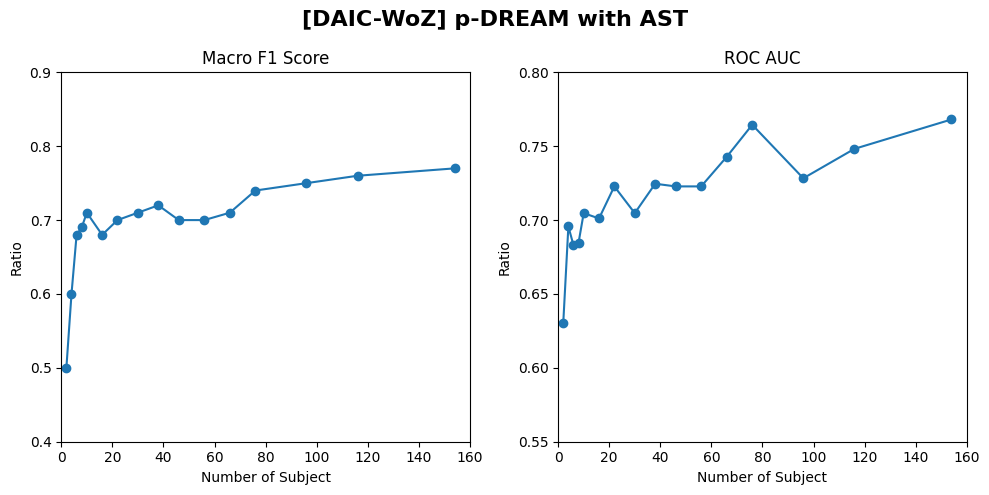

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 준비
X = [2, 4, 6, 8, 10, 16, 22, 30, 38, 46, 56, 66, 76, 96, 116, 154]
prec = [0.41, 0.46, 0.58, 0.67, 0.64, 0.53, 0.56, 0.64, 0.62, 0.56, 0.56, 0.56, 0.59, 0.86, 0.78, 0.73]
rec = [1, 1, 0.58, 0.5, 0.58, 0.75, 0.75, 0.58, 0.67, 0.75, 0.75, 0.83, 0.83, 0.5, 0.58, 0.67]
f1 = [0.59, 0.63, 0.58, 0.57, 0.61, 0.62, 0.64, 0.61, 0.64, 0.64, 0.64, 0.67, 0.69, 0.63, 0.67, 0.7]
macro_f1 = [0.5, 0.6, 0.68, 0.69, 0.71, 0.68, 0.7, 0.71, 0.72, 0.7, 0.7, 0.71, 0.74, 0.75, 0.76, 0.77]
spec = [0.26, 0.39, 0.78, 0.87, 0.83, 0.65, 0.7, 0.83, 0.78, 0.7, 0.7, 0.65, 0.7, 0.96, 0.91, 0.87]
sens = [1, 1, 0.58, 0.5, 0.58, 0.75, 0.75, 0.58, 0.67, 0.75, 0.75, 0.83, 0.83, 0.5, 0.58, 0.67]
roc_auc = [0.6304, 0.6957, 0.683, 0.6848, 0.7047, 0.7011, 0.7228, 0.7047, 0.7246, 0.7228, 0.7228, 0.7428, 0.7645, 0.7283, 0.7482, 0.7681]


# subplot 설정
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# 각 subplot에 데이터 그리기
axs[0].plot(X, macro_f1, marker='o', linestyle='-')
axs[0].set_title('Macro F1 Score')
axs[0].set_xlabel('Number of Subject')
axs[0].set_ylabel('Ratio')
axs[0].set_xlim([0, 160])
axs[0].set_ylim([0.4, 0.9])

axs[1].plot(X, roc_auc, marker='o', linestyle='-')
axs[1].set_title('ROC AUC')
axs[1].set_xlabel('Number of Subject')
axs[1].set_ylabel('Ratio')
axs[1].set_xlim([0, 160])
axs[1].set_ylim([0.55, 0.8])
#axs[1].set_yticks([0.5,0.6,0.7,0.8,0.9])

# 레이아웃 조정 및 그래프 표시
plt.suptitle("[DAIC-WoZ] p-DREAM with AST", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


---

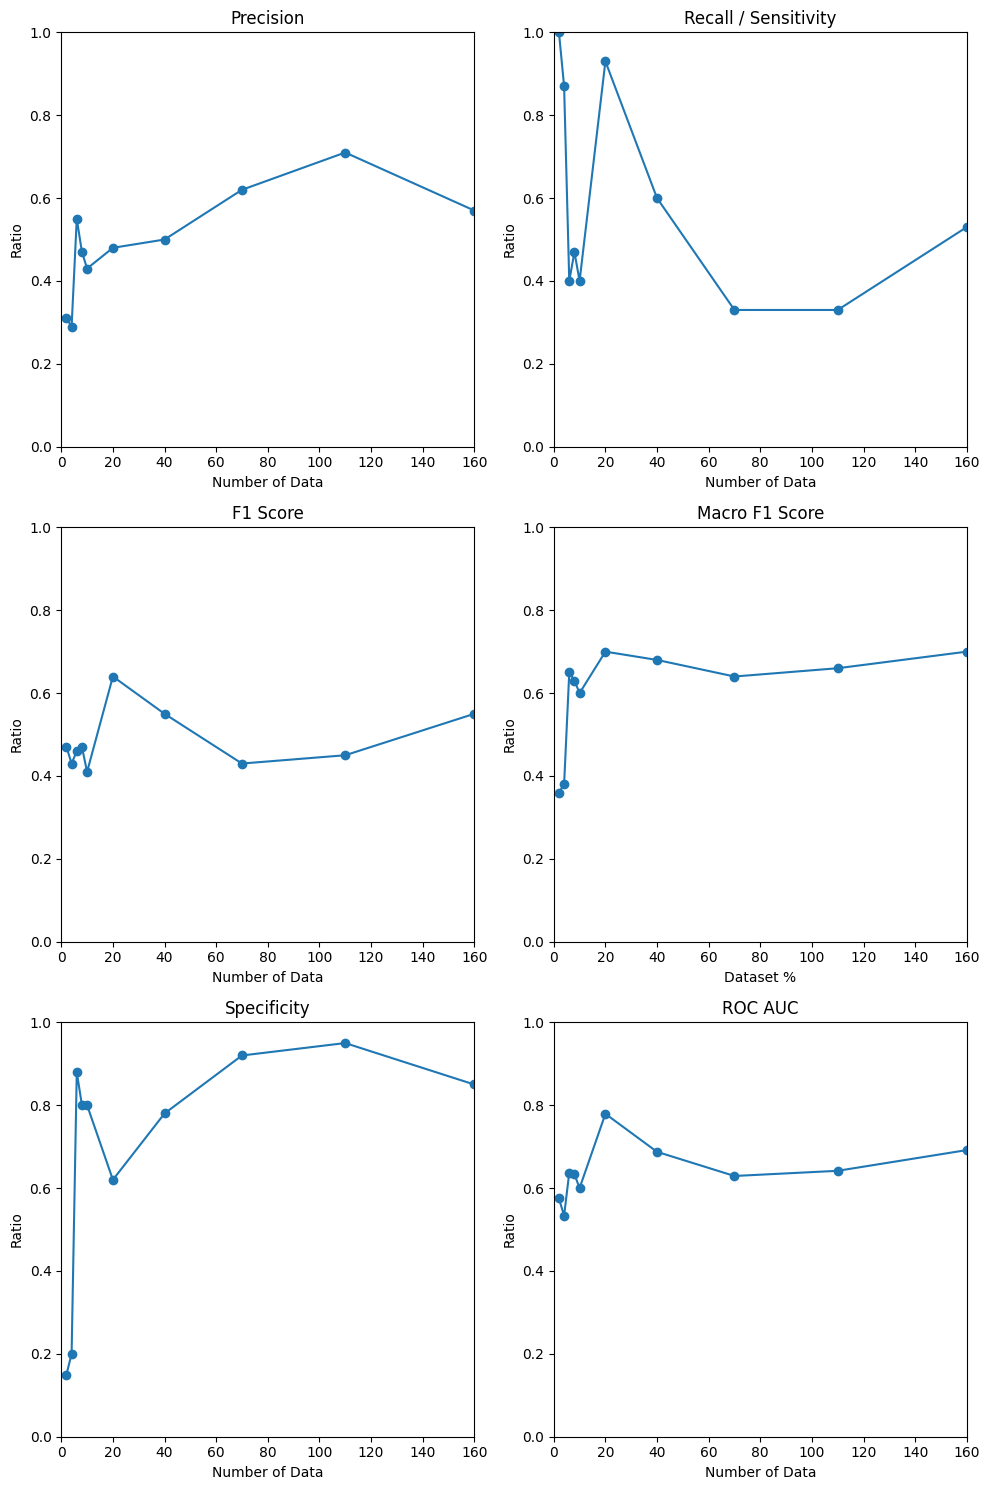

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 준비
X = [2, 4, 6, 8, 10, 20, 40, 70, 110, 160, 219]
prec     = [0.31, 0.29, 0.55, 0.47, 0.43, 0.48, 0.50, 0.62, 0.71, 0.57, 0.67]
rec      = [1.00, 0.87, 0.40, 0.47, 0.40, 0.93, 0.60, 0.33, 0.33, 0.53, 0.67]
f1       = [0.47, 0.43, 0.46, 0.47, 0.41, 0.64, 0.55, 0.43, 0.45, 0.55, 0.67]
macro_f1 = [0.36, 0.38, 0.65, 0.63, 0.60, 0.70, 0.68, 0.64, 0.66, 0.70, 0.77]
spec     = [0.15, 0.20, 0.88, 0.80, 0.80, 0.62, 0.78, 0.92, 0.95, 0.85, 0.88]
sens     = [1.00, 0.87, 0.40, 0.47, 0.40, 0.93, 0.60, 0.33, 0.33, 0.53, 0.67]
roc_auc  = [0.5750, 0.5333, 0.6375, 0.6333, 0.6000, 0.7792, 0.6875, 0.6292, 0.6417, 0.6917, 0.7708]

# subplot 설정
fig, axs = plt.subplots(3, 2, figsize=(10, 15))

# 각 subplot에 데이터 그리기
axs[0, 0].plot(X, prec, marker='o', linestyle='-')
axs[0, 0].set_title('Precision')
axs[0, 0].set_xlabel('Number of Data')
axs[0, 0].set_ylabel('Ratio')
axs[0, 0].set_xlim([0, 160])
axs[0, 0].set_ylim([0, 1])

axs[0, 1].plot(X, rec, marker='o', linestyle='-')
axs[0, 1].set_title('Recall / Sensitivity')
axs[0, 1].set_xlabel('Number of Data')
axs[0, 1].set_ylabel('Ratio')
axs[0, 1].set_xlim([0, 160])
axs[0, 1].set_ylim([0, 1])

axs[1, 0].plot(X, f1, marker='o', linestyle='-')
axs[1, 0].set_title('F1 Score')
axs[1, 0].set_xlabel('Number of Data')
axs[1, 0].set_ylabel('Ratio')
axs[1, 0].set_xlim([0, 160])
axs[1, 0].set_ylim([0, 1])

axs[1, 1].plot(X, macro_f1, marker='o', linestyle='-')
axs[1, 1].set_title('Macro F1 Score')
axs[1, 1].set_xlabel('Dataset %')
axs[1, 1].set_ylabel('Ratio')
axs[1, 1].set_xlim([0, 160])
axs[1, 1].set_ylim([0, 1])

axs[2, 0].plot(X, spec, marker='o', linestyle='-')
axs[2, 0].set_title('Specificity')
axs[2, 0].set_xlabel('Number of Data')
axs[2, 0].set_ylabel('Ratio')
axs[2, 0].set_xlim([0, 160])
axs[2, 0].set_ylim([0, 1])

axs[2, 1].plot(X, roc_auc, marker='o', linestyle='-')
axs[2, 1].set_title('ROC AUC')
axs[2, 1].set_xlabel('Number of Data')
axs[2, 1].set_ylabel('Ratio')
axs[2, 1].set_xlim([0, 160])
axs[2, 1].set_ylim([0, 1])

# 레이아웃 조정 및 그래프 표시
plt.tight_layout()
plt.show()


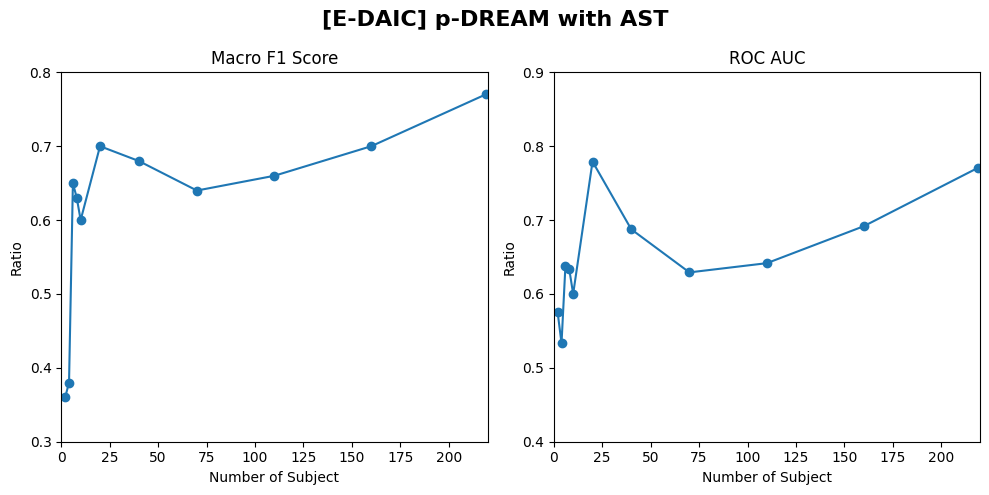

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 준비
X = [2, 4, 6, 8, 10, 20, 40, 70, 110, 160, 219]
prec     = [0.31, 0.29, 0.55, 0.47, 0.43, 0.48, 0.50, 0.62, 0.71, 0.57, 0.67]
rec      = [1.00, 0.87, 0.40, 0.47, 0.40, 0.93, 0.60, 0.33, 0.33, 0.53, 0.67]
f1       = [0.47, 0.43, 0.46, 0.47, 0.41, 0.64, 0.55, 0.43, 0.45, 0.55, 0.67]
macro_f1 = [0.36, 0.38, 0.65, 0.63, 0.60, 0.70, 0.68, 0.64, 0.66, 0.70, 0.77]
spec     = [0.15, 0.20, 0.88, 0.80, 0.80, 0.62, 0.78, 0.92, 0.95, 0.85, 0.88]
sens     = [1.00, 0.87, 0.40, 0.47, 0.40, 0.93, 0.60, 0.33, 0.33, 0.53, 0.67]
roc_auc  = [0.5750, 0.5333, 0.6375, 0.6333, 0.6000, 0.7792, 0.6875, 0.6292, 0.6417, 0.6917, 0.7708]


# subplot 설정
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# 각 subplot에 데이터 그리기
axs[0].plot(X, macro_f1, marker='o', linestyle='-')
axs[0].set_title('Macro F1 Score')
axs[0].set_xlabel('Number of Subject')
axs[0].set_ylabel('Ratio')
axs[0].set_xlim([0, 220])
axs[0].set_ylim([0.3, 0.8])

axs[1].plot(X, roc_auc, marker='o', linestyle='-')
axs[1].set_title('ROC AUC')
axs[1].set_xlabel('Number of Subject')
axs[1].set_ylabel('Ratio')
axs[1].set_xlim([0, 220])
axs[1].set_ylim([0.4, 0.9])
axs[1].set_yticks([0.4,0.5,0.6,0.7,0.8,0.9])

# 레이아웃 조정 및 그래프 표시
plt.suptitle("[E-DAIC] p-DREAM with AST", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


---

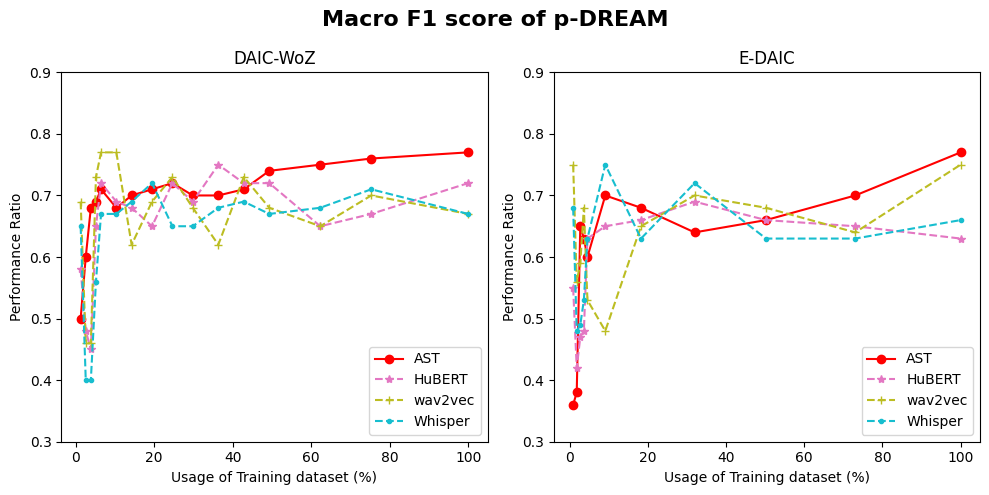

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터 준비
d_X       = [2/154*100, 4/154*100, 6/154*100, 8/154*100, 10/154*100, 16/154*100, 22/154*100, 30/154*100, 38/154*100, 46/154*100, 56/154*100, 66/154*100, 76/154*100, 96/154*100, 116/154*100, 154/154*100]
d_ast     = [0.50, 0.60, 0.68, 0.69, 0.71, 0.68, 0.70, 0.71, 0.72, 0.70, 0.70, 0.71, 0.74, 0.75, 0.76, 0.77]
d_hubert  = [0.58, 0.48, 0.45, 0.65, 0.72, 0.69, 0.68, 0.65, 0.72, 0.69, 0.75, 0.72, 0.72, 0.65, 0.67, 0.72]
d_wav2vec = [0.69, 0.46, 0.46, 0.73, 0.77, 0.77, 0.62, 0.69, 0.73, 0.68, 0.62, 0.73, 0.68, 0.65, 0.70, 0.67]
d_whisper = [0.65, 0.40, 0.40, 0.56, 0.67, 0.67, 0.69, 0.72, 0.65, 0.65, 0.68, 0.69, 0.67, 0.68, 0.71, 0.67]

e_X       = [2/219*100, 4/219*100, 6/219*100, 8/219*100, 10/219*100, 20/219*100, 40/219*100, 70/219*100, 110/219*100, 160/219*100, 219/219*100]
e_ast     = [0.36, 0.38, 0.65, 0.63, 0.60, 0.70, 0.68, 0.64, 0.66, 0.70, 0.77]
e_hubert  = [0.55, 0.42, 0.47, 0.48, 0.63, 0.65, 0.66, 0.69, 0.66, 0.65, 0.63]
e_wav2vec = [0.75, 0.56, 0.59, 0.68, 0.53, 0.48, 0.65, 0.70, 0.68, 0.64, 0.75]
e_whisper = [0.68, 0.48, 0.49, 0.53, 0.63, 0.75, 0.63, 0.72, 0.63, 0.63, 0.66]


# subplot 설정
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# 각 subplot에 데이터 그리기
axs[0].plot(d_X, d_ast, marker='o', linestyle='-', color='red', label="AST")
axs[0].plot(d_X, d_hubert, marker='*', linestyle='--', color='tab:pink', label="HuBERT")
axs[0].plot(d_X, d_wav2vec, marker='+', linestyle='--', color='tab:olive', label="wav2vec")
axs[0].plot(d_X, d_whisper, marker='.', linestyle='--', color='tab:cyan', label="Whisper")
axs[0].set_title('DAIC-WoZ')
axs[0].set_xlabel('Usage of Training dataset (%)')
axs[0].set_ylabel('Performance Ratio')
axs[0].legend()
#axs[0].set_xlim([0, 220])
#axs[1].set_xticks([0, 20, 40, 60, 80, 100, 120, 140, 100])
axs[0].set_ylim([0.3, 0.9])

axs[1].plot(e_X, e_ast, marker='o', linestyle='-', color='red', label="AST")
axs[1].plot(e_X, e_hubert, marker='*', linestyle='--', color='tab:pink', label="HuBERT")
axs[1].plot(e_X, e_wav2vec, marker='+', linestyle='--', color='tab:olive', label="wav2vec")
axs[1].plot(e_X, e_whisper, marker='.', linestyle='--', color='tab:cyan', label="Whisper")
axs[1].set_title('E-DAIC')
axs[1].set_xlabel('Usage of Training dataset (%)')
axs[1].set_ylabel('Performance Ratio')
axs[1].legend()
#axs[1].set_xlim([0, 220])
axs[1].set_ylim([0.3, 0.9])
#axs[1].set_yticks([0.4,0.5,0.6,0.7,0.8,0.9])

# 레이아웃 조정 및 그래프 표시
plt.suptitle("Macro F1 score of p-DREAM", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
